<a href="https://colab.research.google.com/github/hafnailmy-bip/pertemuan4/blob/main/PCD_Pratikum_2_Latihan_3_Pertemuan_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload video yang ingin diproses


Saving Foto Tugas.jpeg to Foto Tugas.jpeg


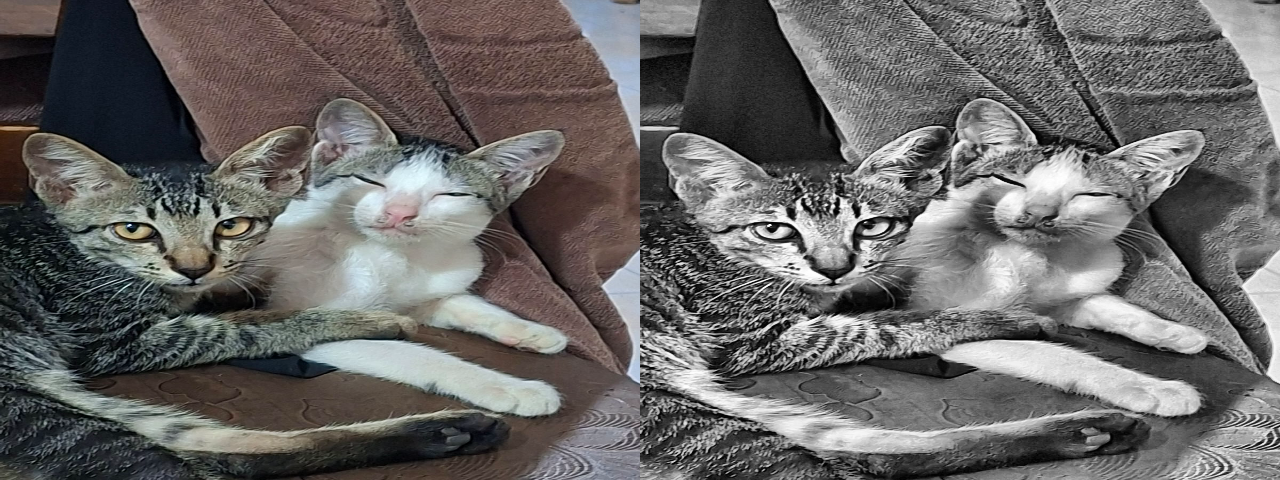

Processing selesai


In [3]:
# ============================================
# REAL-TIME VIDEO ENHANCEMENT
# Google Colab Ready
# ============================================

# 1. INSTALL & IMPORT LIBRARY
!pip -q install opencv-python-headless matplotlib

import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import files

# ============================================
# 2. CLASS REAL-TIME ENHANCEMENT
# ============================================

class RealTimeEnhancement:

    def __init__(self, target_fps=30, buffer_size=5):
        self.target_fps = target_fps
        self.history_buffer = []
        self.buffer_size = buffer_size
        self.frame_time = 1 / target_fps

    def temporal_smoothing(self, frame):
        """
        Maintain temporal consistency using previous frames
        """
        self.history_buffer.append(frame)

        if len(self.history_buffer) > self.buffer_size:
            self.history_buffer.pop(0)

        avg_frame = np.mean(self.history_buffer, axis=0).astype(np.uint8)

        return avg_frame

    def enhance_frame(self, frame, enhancement_type='adaptive'):
        """
        Enhance single frame with real-time constraints
        """

        # Convert to grayscale if needed
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        if enhancement_type == 'adaptive':

            # CLAHE (Adaptive Histogram Equalization)
            clahe = cv2.createCLAHE(
                clipLimit=2.0,
                tileGridSize=(8,8)
            )

            enhanced = clahe.apply(gray)

        elif enhancement_type == 'gamma':

            gamma = 1.5
            invGamma = 1.0 / gamma

            table = np.array([
                ((i / 255.0) ** invGamma) * 255
                for i in np.arange(256)
            ]).astype("uint8")

            enhanced = cv2.LUT(gray, table)

        elif enhancement_type == 'sharpen':

            kernel = np.array([
                [0,-1,0],
                [-1,5,-1],
                [0,-1,0]
            ])

            enhanced = cv2.filter2D(gray, -1, kernel)

        else:
            enhanced = gray

        # Convert back to BGR
        enhanced = cv2.cvtColor(enhanced, cv2.COLOR_GRAY2BGR)

        # Temporal smoothing
        enhanced = self.temporal_smoothing(enhanced)

        return enhanced

# ============================================
# 3. UPLOAD VIDEO
# ============================================

print("Upload video yang ingin diproses")
uploaded = files.upload()

video_path = list(uploaded.keys())[0]

# ============================================
# 4. VIDEO PROCESSING
# ============================================

cap = cv2.VideoCapture(video_path)

enhancer = RealTimeEnhancement(target_fps=30)

frame_count = 0

while cap.isOpened():

    start_time = time.time()

    ret, frame = cap.read()

    if not ret:
        break

    # Resize agar lebih ringan
    frame = cv2.resize(frame, (640, 480))

    # Enhancement
    enhanced = enhancer.enhance_frame(frame, 'adaptive')

    # Display original vs enhanced
    combined = np.hstack((frame, enhanced))

    cv2_imshow(combined)

    frame_count += 1

    # Stop setelah beberapa frame (agar Colab tidak overload)
    if frame_count > 100:
        break

    process_time = time.time() - start_time

    # Maintain target FPS
    delay = enhancer.frame_time - process_time

    if delay > 0:
        time.sleep(delay)

cap.release()

print("Processing selesai")